## MAT 400 ERIC BAAH - CRYPTO FUNDS LOST PREDICTION

In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.utils import resample
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc
from ISLP import load_data
import warnings
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from ISLP.models import bs, ns
from ISLP.pygam import (approx_lam,degrees_of_freedom, plot as plot_gam, anova as anova_gam)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from ISLP.models import (ModelSpec as MS, summarize, poly)
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,export_text)
import seaborn as sns
from xgboost import XGBRegressor as XGB
from lightgbm import LGBMRegressor as LGBMR
from pygam import (s as s_gam, l as l_gam, f as f_gam, LinearGAM, LogisticGAM)
from ISLP.transforms import (BSpline, NaturalSpline)
from ISLP.models import bs, ns
from ISLP.pygam import (approx_lam,degrees_of_freedom, plot as plot_gam, anova as anova_gam)
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Lasso
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import GridSearchCV

## SUMMARY STATISTICS

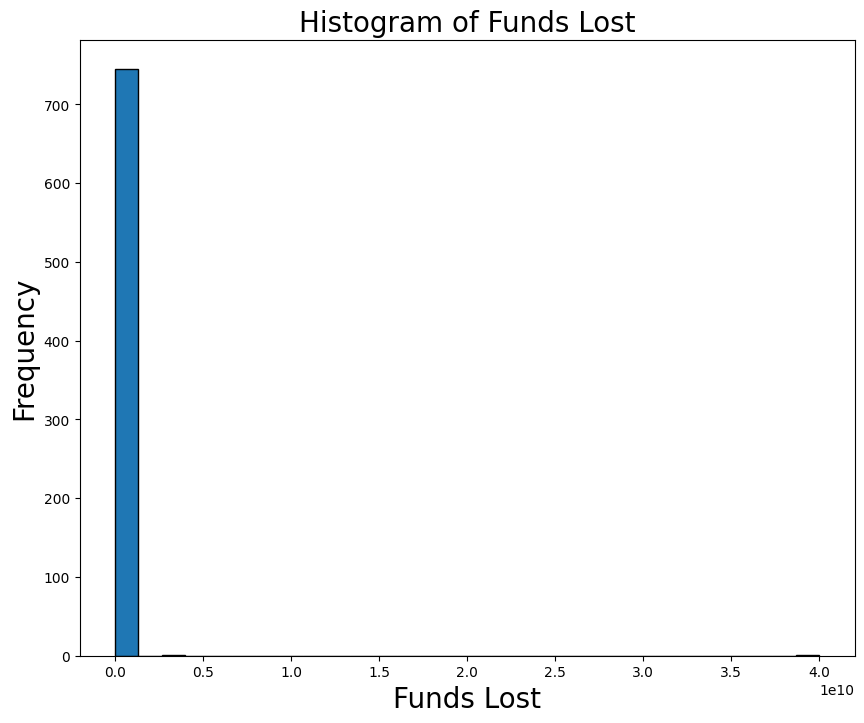

In [2]:
# Load the dataset
data = pd.read_csv("data_cleaned.csv") 

# Add labels and title
ax = plt.subplots(figsize=(10,8))[1]
plt.hist(data['Funds.Lost'], bins=30, edgecolor='black')
plt.xlabel('Funds Lost', fontsize=20)
plt.ylabel('Frequency', fontsize=20)
plt.title('Histogram of Funds Lost', fontsize=20)
plt.savefig('Lost_Funds_Hist.eps', format='eps')
plt.show()

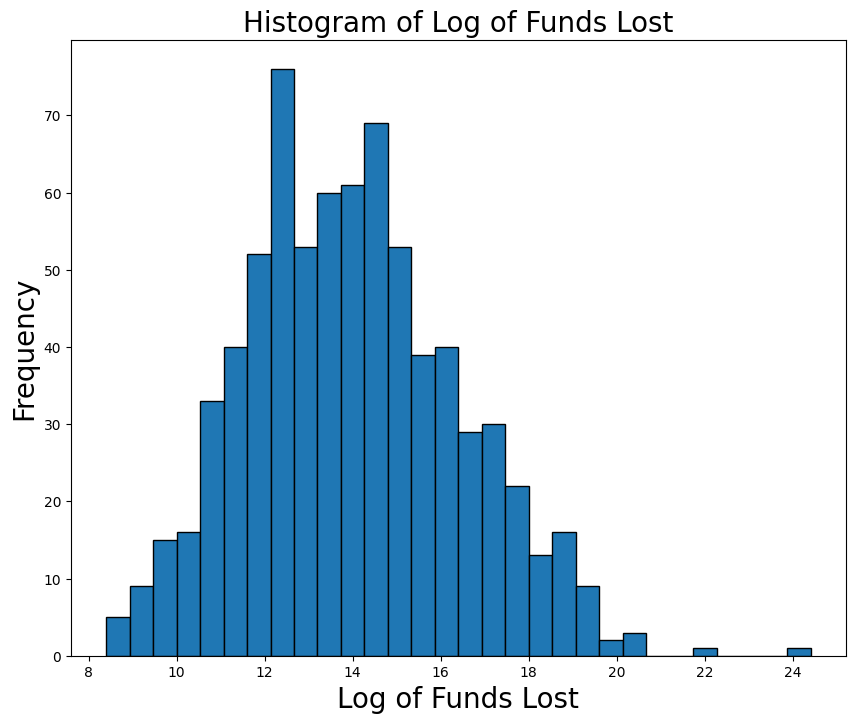

In [3]:
data['Funds Lost'] = np.log(data['Funds.Lost'])
# Add labels and title
ax = plt.subplots(figsize=(10,8))[1]
plt.hist(data['Funds Lost'], bins=30, edgecolor='black')
plt.xlabel('Log of Funds Lost', fontsize=20)
plt.ylabel('Frequency', fontsize=20)
plt.title('Histogram of Log of Funds Lost', fontsize=20)
plt.savefig('Log_Lost_Funds_Hist.eps', format='eps')
plt.show()


In [4]:
# Convert the 'date' column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Calculate days since a reference date
reference_date = pd.Timestamp('2011-01-01')
data['Days_Since_2011'] = (data['Date'] - reference_date).dt.days

data = data.drop(columns=['Quick Summary', 'Details', 'Tokens', 'Date', 'Year','Funds.Lost'])


In [5]:

data1 = pd.get_dummies(data, drop_first=False)

# Generate summary statistics

# Use pandas to set float formatting (for the whole session)
pd.set_option('display.float_format', '{:.3f}'.format)

# Specify the statistics you want to include
summary_stats = data1.agg(['mean', 'std', 'min', 'max'])

sum_rounded  = summary_stats.round(3)

# Transpose the summary statistics
transposed_summary = sum_rounded.T

# Export to LaTeX
latex_table = transposed_summary.to_latex()

print(latex_table)

# Export the LaTeX table directly to a file
transposed_summary.to_latex('summary_statistics_table1.tex')

# Read the file content
input_file = 'summary_statistics_table1.tex'
output_file = 'escaped_summary_statistics_table2.tex'

# Open the file, replace underscores, and save to a new file
with open(input_file, 'r') as file:
    content = file.read()

# Add a backslash before every underscore
modified_content = content.replace('_', r'\_')

# Write the modified content to a new file
with open(output_file, 'w') as file:
    file.write(modified_content)

print(f"Modified content has been saved to {output_file}")


\begin{tabular}{lllll}
\toprule
 & mean & std & min & max \\
\midrule
Funds Lost & 13.999000 & 2.419000 & 8.398000 & 24.412000 \\
Days_Since_2011 & 3958.253000 & 964.037000 & 163.000000 & 4973.000000 \\
Category_Borrowing & 0.111111 & 0.314480 & False & True \\
Category_Bridge & 0.034806 & 0.183411 & False & True \\
Category_CeFi & 0.143240 & 0.350552 & False & True \\
Category_Exchange & 0.143240 & 0.350552 & False & True \\
Category_GamingM & 0.038822 & 0.193300 & False & True \\
Category_NFT & 0.054886 & 0.227911 & False & True \\
Category_Other & 0.234270 & 0.423826 & False & True \\
Category_Stablecoin & 0.025435 & 0.157548 & False & True \\
Category_Token & 0.119143 & 0.324174 & False & True \\
Category_YieldAggr & 0.095047 & 0.293476 & False & True \\
Issue_AccessControl & 0.251673 & 0.434265 & False & True \\
Issue_FlashLoanAttack & 0.159304 & 0.366204 & False & True \\
Issue_OracleIssue & 0.022758 & 0.149230 & False & True \\
Issue_Other & 0.485944 & 0.500137 & False & True \\

## LINEAR MODELS

In [6]:

data = pd.get_dummies(data, drop_first=True)
X = MS(data.drop(columns=['Funds Lost'])).fit_transform(data) 
y = data['Funds Lost']  # Target variable is 'Funds Lost'

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [7]:
Linear_Model1=sm.OLS(y_train, X_train).fit()
print(Linear_Model1.summary())

                            OLS Regression Results                            
Dep. Variable:             Funds Lost   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     9.546
Date:                Thu, 05 Dec 2024   Prob (F-statistic):           2.56e-24
Time:                        23:36:40   Log-Likelihood:                -1300.4
No. Observations:                 597   AIC:                             2641.
Df Residuals:                     577   BIC:                             2729.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept                12.06

In [8]:
# Publication tables

from stargazer.stargazer import Stargazer
stargazer = Stargazer([Linear_Model1])
latex_output = stargazer.render_latex()
print(stargazer.render_latex())

# Optionally, you can export the LaTeX table directly to a file
with open("regression_output.tex", "w") as file:
    file.write(latex_output)

# Read the file content
input_file = 'regression_output.tex'
output_file = 'regression_output_corrected.tex'

# Open the file, replace underscores, and save to a new file
with open(input_file, 'r') as file:
    content = file.read()

# Add a backslash before every underscore
modified_content = content.replace('_', r'\_')

# Write the modified content to a new file
with open(output_file, 'w') as file:
    file.write(modified_content)

print(f"Modified content has been saved to {output_file}")

\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{1}{c}{\textit{Dependent variable: Funds Lost}} \
\cr \cline{2-2}
\\[-1.8ex] & (1) \\
\hline \\[-1.8ex]
 Category_Bridge & 1.185$^{**}$ \\
& (0.565) \\
 Category_CeFi & 0.523$^{}$ \\
& (0.580) \\
 Category_Exchange & -0.379$^{}$ \\
& (0.371) \\
 Category_GamingM & -0.954$^{*}$ \\
& (0.563) \\
 Category_NFT & -1.992$^{***}$ \\
& (0.483) \\
 Category_Other & -0.624$^{*}$ \\
& (0.349) \\
 Category_Stablecoin & 1.810$^{***}$ \\
& (0.652) \\
 Category_Token & -2.330$^{***}$ \\
& (0.402) \\
 Category_YieldAggr & -0.502$^{}$ \\
& (0.416) \\
 Chain_BSC & 0.323$^{}$ \\
& (0.487) \\
 Chain_CEX & 1.455$^{*}$ \\
& (0.754) \\
 Chain_ETH & 1.087$^{**}$ \\
& (0.472) \\
 Chain_Other & 0.925$^{*}$ \\
& (0.502) \\
 Days_Since_2011 & 0.001$^{***}$ \\
& (0.000) \\
 Issue_FlashLoanAttack & -0.636$^{**}$ \\
& (0.324) \\
 Issue_OracleIssue & 0.309$^{}$ \\
& (0.639) \\
 Issue_Other & -0.565

In [9]:
lm = LinearRegression()
Linear_Model1 = lm.fit(X_train, y_train)

# Predict on the test set
y_pred = Linear_Model1.predict(X_test)

# Calculate test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f"Linear Model Test MSE: {test_mse}")

Linear Model Test MSE: 4.314387112428238


In [10]:
# GLM MODEL

# Fit a GLM with Gamma distribution and log link
gamma_model = sm.GLM(y_train, X_train, family=sm.families.Gamma(link=sm.families.links.log()))
gamma_results = gamma_model.fit()

print(gamma_results.summary())

# Make predictions
gamma_predictions = gamma_results.predict(X_test)

# Compute test error for Gamma model
gamma_mse = mean_squared_error(y_test, gamma_predictions)
gamma_mae = mean_absolute_error(y_test, gamma_predictions)

print(f"GLM Model Test MSE: {gamma_mse:.4f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Funds Lost   No. Observations:                  597
Model:                            GLM   Df Residuals:                      577
Model Family:                   Gamma   Df Model:                           19
Link Function:                    log   Scale:                        0.023842
Method:                          IRLS   Log-Likelihood:                -1294.6
Date:                Thu, 05 Dec 2024   Deviance:                       14.003
Time:                        23:36:41   Pearson chi2:                     13.8
No. Iterations:                     9   Pseudo R-squ. (CS):             0.2685
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept                 2.50

C:\Users\erick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [11]:
# Publication tables

stargazer = Stargazer([gamma_results])
latex_output = stargazer.render_latex()
print(stargazer.render_latex())

# Optionally, you can export the LaTeX table directly to a file
with open("GLM_reg_output.tex", "w") as file:
    file.write(latex_output)

# Read the file content
input_file = 'GLM_reg_output.tex'
output_file = 'GLM_reg_output_corrected.tex'

# Open the file, replace underscores, and save to a new file
with open(input_file, 'r') as file:
    content = file.read()

# Add a backslash before every underscore
modified_content = content.replace('_', r'\_')

# Write the modified content to a new file
with open(output_file, 'w') as file:
    file.write(modified_content)

print(f"Modified content has been saved to {output_file}")

\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{1}{c}{\textit{Dependent variable: Funds Lost}} \
\cr \cline{2-2}
\\[-1.8ex] & (1) \\
\hline \\[-1.8ex]
 Category_Bridge & 0.077$^{*}$ \\
& (0.040) \\
 Category_CeFi & 0.033$^{}$ \\
& (0.041) \\
 Category_Exchange & -0.026$^{}$ \\
& (0.026) \\
 Category_GamingM & -0.070$^{*}$ \\
& (0.040) \\
 Category_NFT & -0.147$^{***}$ \\
& (0.034) \\
 Category_Other & -0.045$^{*}$ \\
& (0.025) \\
 Category_Stablecoin & 0.118$^{**}$ \\
& (0.046) \\
 Category_Token & -0.179$^{***}$ \\
& (0.029) \\
 Category_YieldAggr & -0.034$^{}$ \\
& (0.030) \\
 Chain_BSC & 0.022$^{}$ \\
& (0.035) \\
 Chain_CEX & 0.100$^{*}$ \\
& (0.054) \\
 Chain_ETH & 0.078$^{**}$ \\
& (0.034) \\
 Chain_Other & 0.064$^{*}$ \\
& (0.036) \\
 Days_Since_2011 & 0.000$^{***}$ \\
& (0.000) \\
 Issue_FlashLoanAttack & -0.045$^{*}$ \\
& (0.023) \\
 Issue_OracleIssue & 0.020$^{}$ \\
& (0.045) \\
 Issue_Other & -0.039$^{

## REGULARIZATION

In [12]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=8)

In [13]:
### Ridge regression
ridge = Ridge(alpha=6.0)

# Fit ridge regression to the data with default lambda
ridge.fit(X_train, y_train)

# Make predictions on the test data
y_pred = ridge.predict(X_test)

# Calculate the Mean Squared Error (MSE) on the test data
mse = mean_squared_error(y_test, y_pred)
print(f"Ridge Model Test MSE: {mse}")

# Ridge coefficients
ridge_coef = ridge.coef_
print(f"Ridge coefficients: {ridge_coef}")


Ridge Model Test MSE: 4.286154567561649
Ridge coefficients: [ 0.          0.51150736  0.27433102  0.14924422 -0.13752383 -0.11378227
 -0.461013   -0.19193321  0.13373654 -0.71353379 -0.1478434  -0.15777093
  0.05471376 -0.24383723 -0.14148128 -0.19896562  0.09355821  0.63752201
  0.57981157  0.38415691]


In [14]:
### Lasso Regression

# Initialize Lasso with a default alpha (regularization strength)
lasso = Lasso(alpha=1)

# Fit the Lasso model to the training data
lasso.fit(X_train, y_train)

# Make predictions on the test data
y_pred = lasso.predict(X_test)

# Calculate the Mean Squared Error (MSE) on the test data
mse = mean_squared_error(y_test, y_pred)
print(f"Lasso Model Test MSE: {mse}")

# Display the Lasso coefficients
print(f"Lasso coefficients: {lasso.coef_}")

Lasso Model Test MSE: 5.306260740615613
Lasso coefficients: [ 0. -0.  0.  0.  0. -0. -0.  0.  0. -0. -0. -0.  0. -0. -0. -0. -0.  0.
  0.  0.]


In [15]:
alphas = np.logspace(-4, 4, 100)  # Lambda values to test

# Use GridSearchCV to find the best alpha (regularization strength)
grid_search = GridSearchCV(Lasso(), param_grid={'alpha': alphas}, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid_search.fit(X_train, y_train)

# Best alpha found by GridSearchCV
best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha from cross-validation: {best_alpha}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best alpha from cross-validation: 0.0016297508346206436


In [16]:
# Refit the Lasso model with the best alpha
lasso_best = Lasso(alpha=best_alpha)
lasso_best.fit(X_train, y_train)

# Make predictions with the best model
y_pred_best = lasso_best.predict(X_test)

# Calculate the Mean Squared Error (MSE) for the best model
mse_best = mean_squared_error(y_test, y_pred_best)
print(f"Lasso Model Test MSE (best model): {mse_best}")
# Display the Lasso coefficients for the best model
print(f"Lasso coefficients (best model): {lasso_best.coef_}")

Lasso Model Test MSE (best model): 4.277787860435441
Lasso coefficients (best model): [ 0.          0.52993683  0.26794984  0.11351114 -0.15058109 -0.11934698
 -0.47375571 -0.20892551  0.12875543 -0.73347609 -0.15631775 -0.15752917
  0.05219289 -0.24568842 -0.14205105 -0.20215181  0.14403909  0.71416671
  0.64028334  0.42792549]


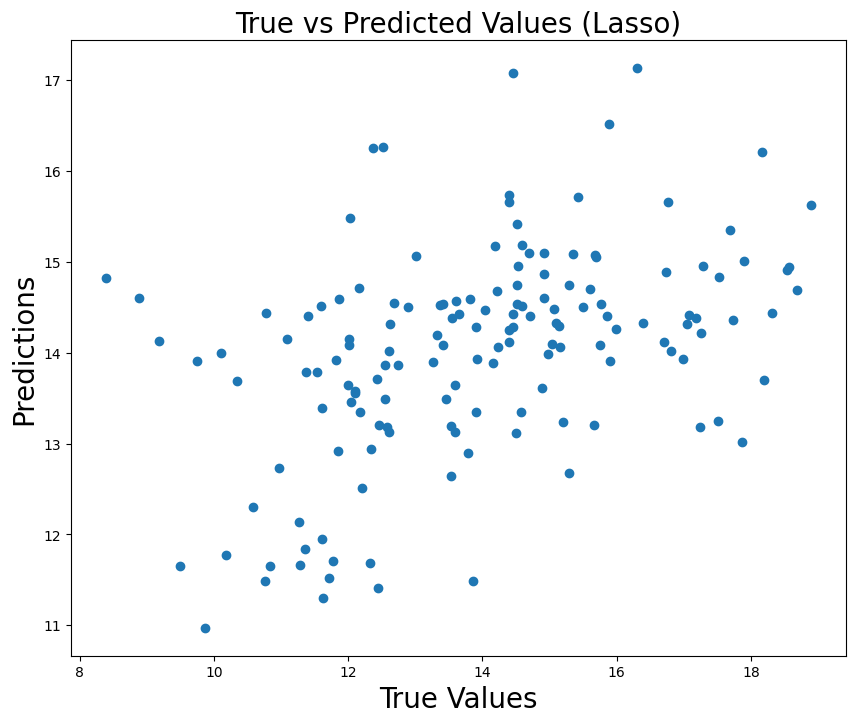

In [17]:
# Visualize the results: Plot the actual vs predicted values
ax = plt.subplots(figsize=(10,8))[1]
plt.scatter(y_test, y_pred_best)
plt.xlabel("True Values", fontsize=20)
plt.ylabel("Predictions", fontsize=20)
plt.title("True vs Predicted Values (Lasso)", fontsize=20)
plt.savefig('Lasso_True_Predicted.eps', format='eps')
plt.show()

In [18]:
# Fit Lasso regression on the full dataset with the optimal alpha (lambda)
lasso_full = Lasso(alpha=best_alpha)  # Use the best alpha found in cross-validation
lasso_full.fit(X_scaled, y)

# Get the coefficients of the full model
lasso_full_coef = lasso_full.coef_
print(f"Lasso coefficients for full dataset: {lasso_full_coef}")


Lasso coefficients for full dataset: [ 0.          0.52711192  0.15258078  0.         -0.20561651 -0.20076903
 -0.52741542 -0.26347081  0.15457518 -0.79572753 -0.16154143 -0.19784786
  0.01434568 -0.29595638 -0.15685141 -0.22134665  0.19435991  0.72688761
  0.67280749  0.44638514]


# TREE-BASED MODELS

In [19]:

X = MS(data.drop(columns=['Funds Lost'])).fit_transform(data) 
y = data['Funds Lost']  # Target variable is 'Funds Lost'

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

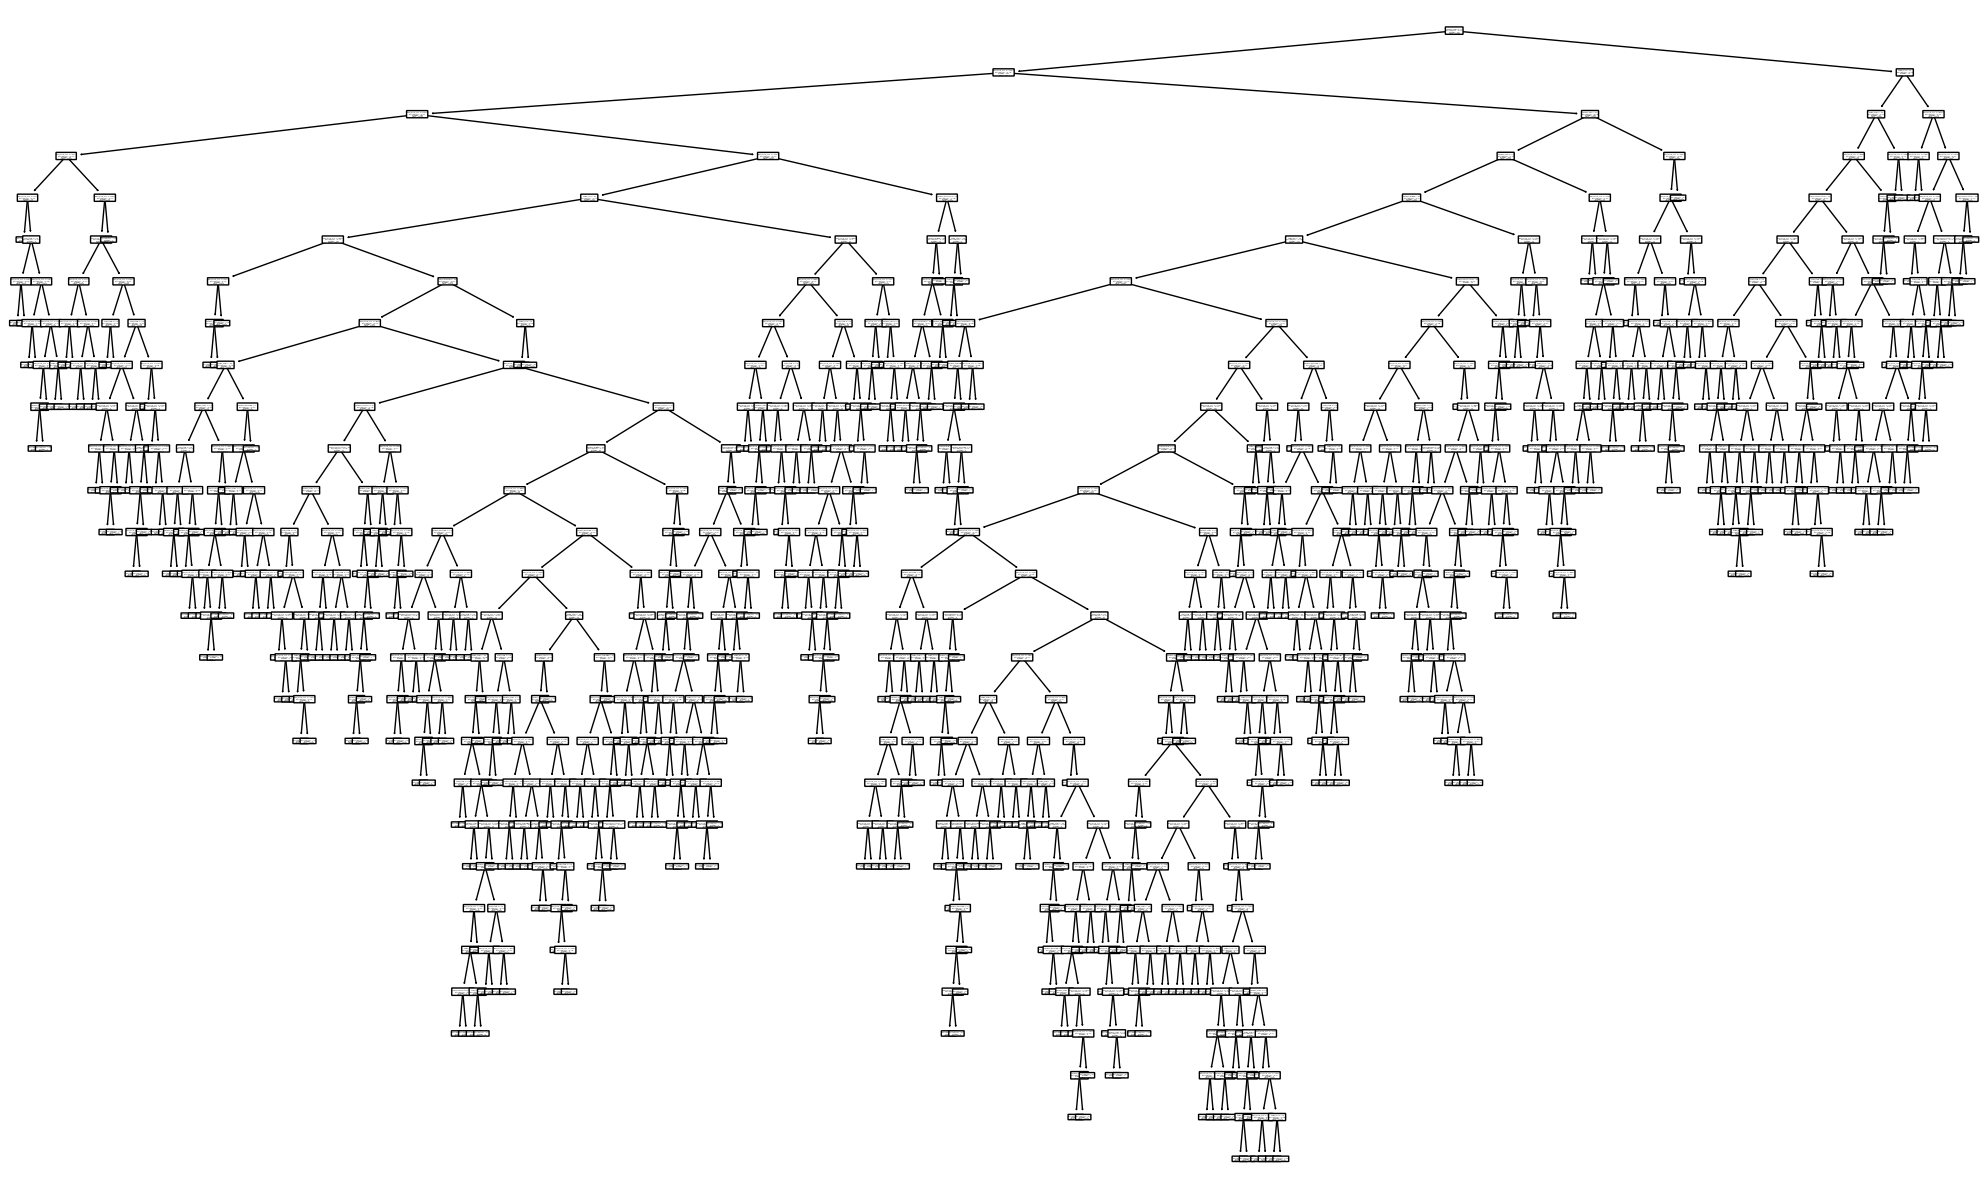

Regression Tree Test MSE: 9.031


In [20]:
# Initialize and fit the regression tree model
reg_tree = DecisionTreeRegressor(random_state=42)
reg_tree.fit(X_train, y_train)

# Plot the regression tree
plt.figure(figsize=(20, 12))
plot_tree(reg_tree, feature_names=X.columns, rounded=True)
plt.tight_layout()
plt.savefig('Tree_full.eps', format='eps')
plt.show()

# Predict on the test set and calculate the MSE
y_pred_tree = reg_tree.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)

print(f"Regression Tree Test MSE: {mse_tree:.3f}")


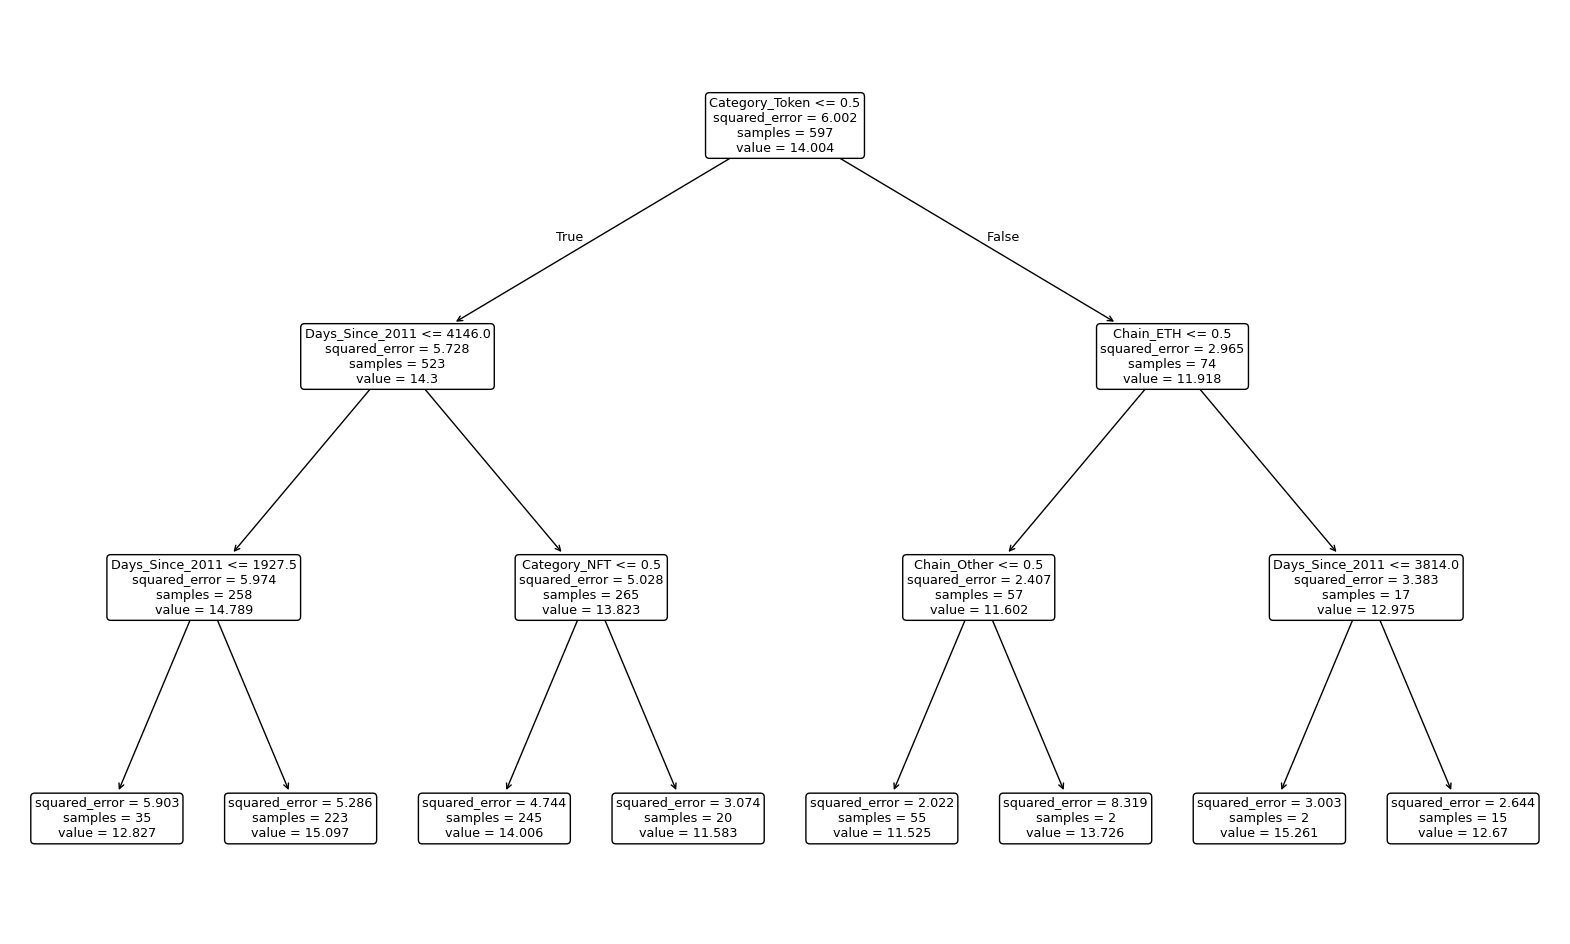

In [21]:

# Initialize and fit the regression tree model
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
reg_tree.fit(X_train, y_train)

# Plot the regression tree
plt.figure(figsize=(20, 12))
plot_tree(reg_tree, feature_names=X.columns, rounded=True)
plt.show()


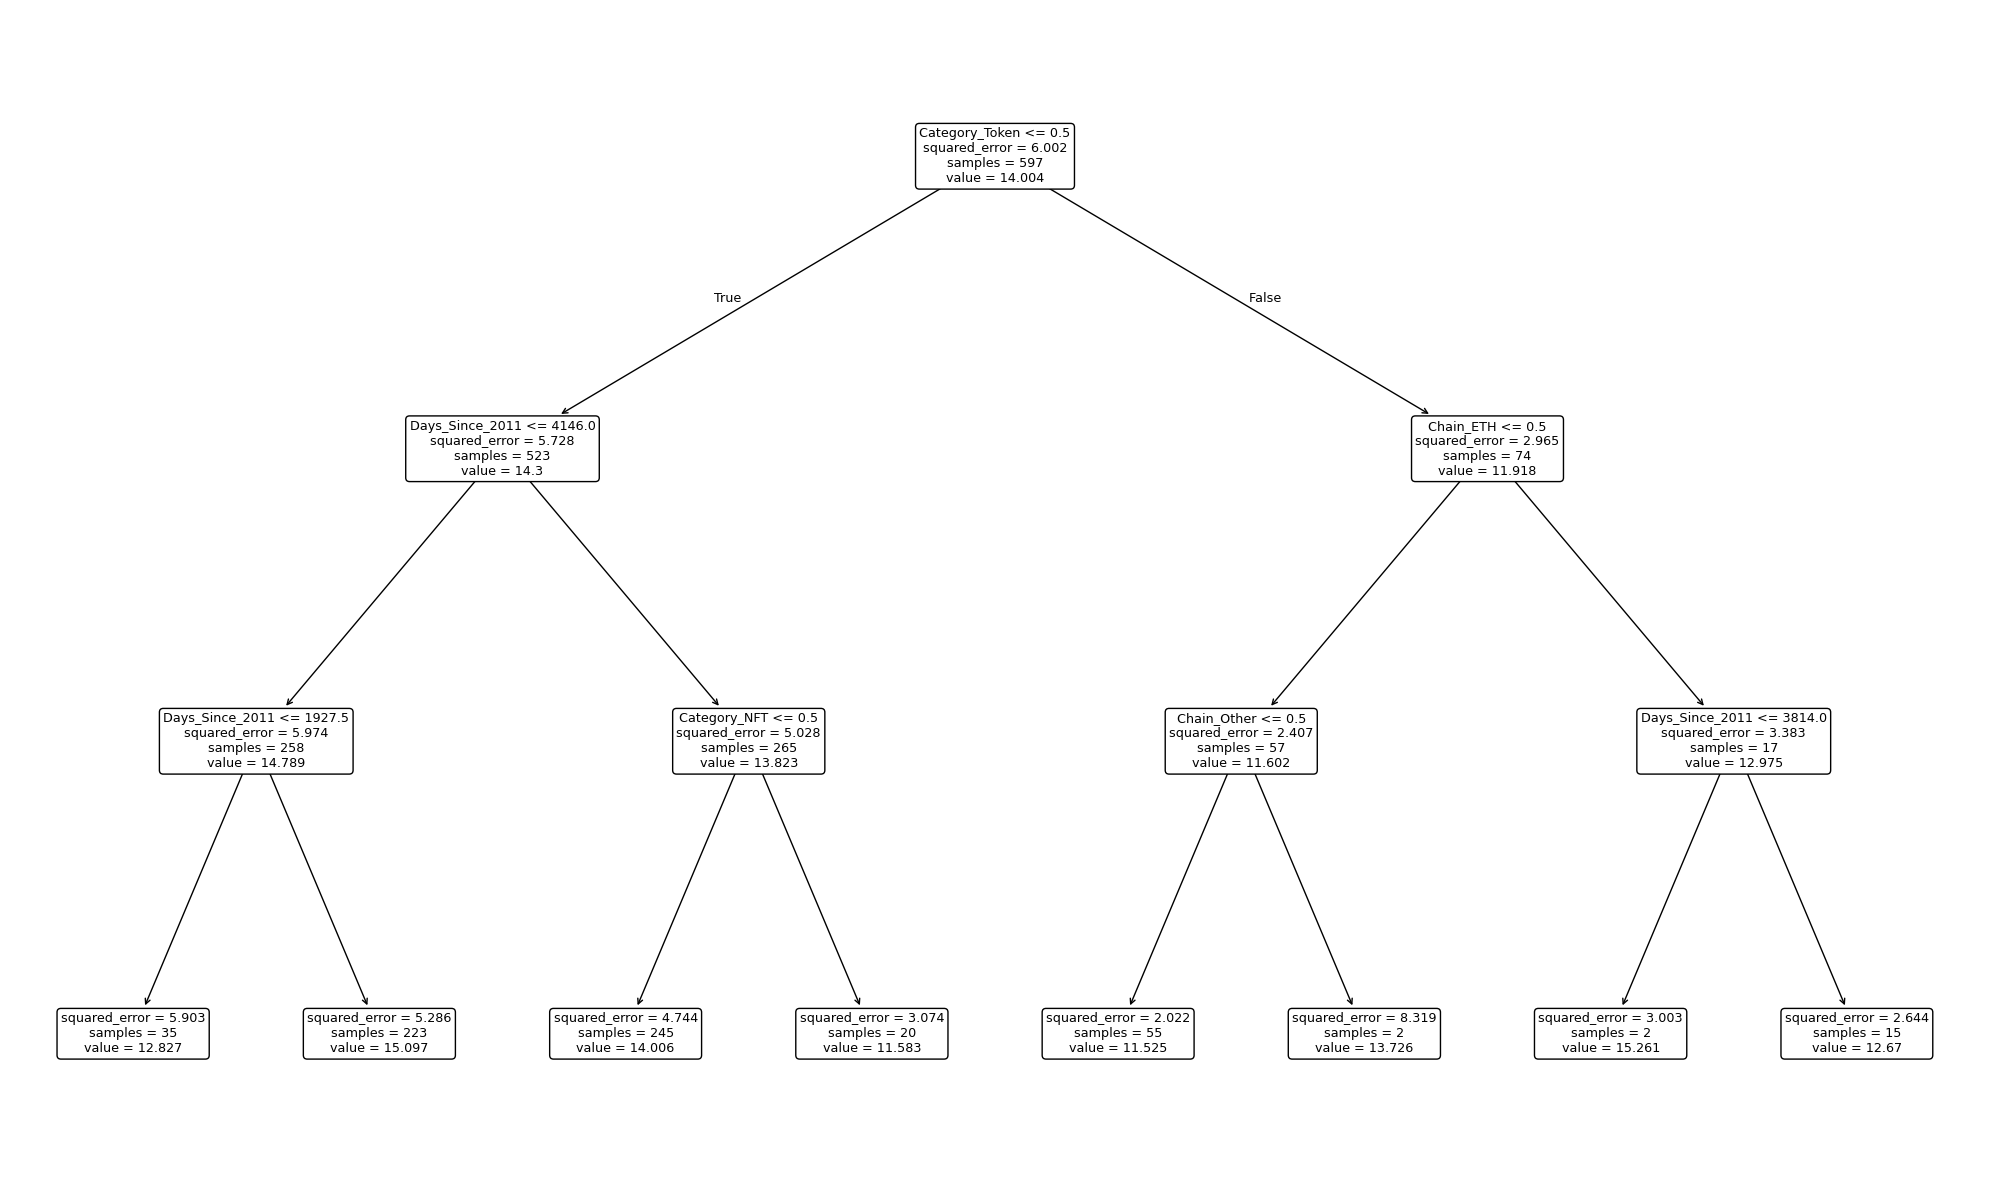

Optimal max_depth: 3
Pruned Regression Tree Test MSE: 4.516


In [22]:
# Set up the parameter grid for max_depth (tree depth)
param_grid = {'max_depth': range(1, 20)}

# Use GridSearchCV to find the best max_depth
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=10, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Get the best tree depth and fit a pruned tree
best_depth = grid_search.best_params_['max_depth']
pruned_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
pruned_tree.fit(X_train, y_train)

# Plot the regression tree
plt.figure(figsize=(20, 12))
plot_tree(pruned_tree, feature_names=X.columns, rounded=True)
plt.tight_layout()
plt.savefig('Tree_opt.eps', format='eps')
plt.show()

# Predict on the test set and calculate MSE
y_pred_pruned = pruned_tree.predict(X_test)
mse_pruned = mean_squared_error(y_test, y_pred_pruned)

print(f"Optimal max_depth: {best_depth}")
print(f"Pruned Regression Tree Test MSE: {mse_pruned:.3f}")

Bagging Model Test MSE: 4.503
                       Importance
Days_Since_2011             0.556
Category_Token              0.098
Issue_Other                 0.040
Category_CeFi               0.034
Category_NFT                0.031
Chain_ETH                   0.028
Chain_Other                 0.025
Category_Bridge             0.025
Chain_BSC                   0.023
Category_Exchange           0.022
Category_Other              0.019
Issue_FlashLoanAttack       0.018
Chain_CEX                   0.015
Category_Stablecoin         0.014
Category_YieldAggr          0.012
Category_GamingM            0.012
Issue_Reentrancy            0.010
Issue_OracleIssue           0.009
Issue_Phishing              0.007
intercept                   0.000


C:\Users\erick\AppData\Local\Temp\ipykernel_56664\521184418.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y=feature_imp_sorted.index, data=feature_imp_sorted, palette='viridis')


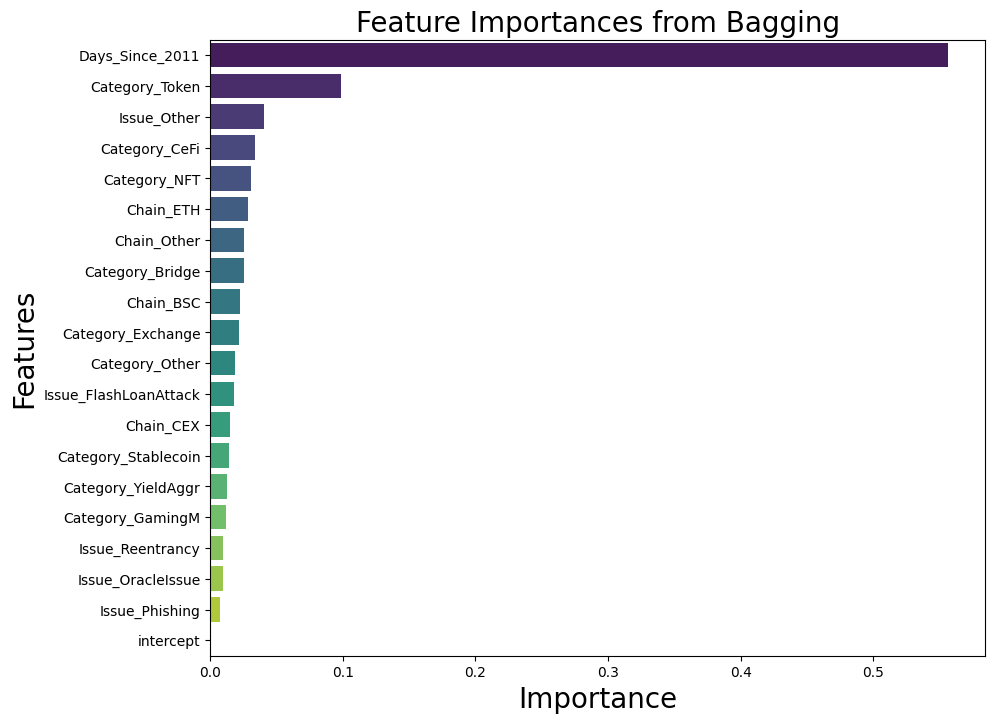

In [23]:
model = MS(data.columns.drop(['Funds Lost']), intercept=True)
D = model.fit_transform(data)
feature_names = list(D.columns)
X = np.asarray(D)

# Initialize and fit a Bagging Regressor
bagging = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)

# Predict on the test set and calculate MSE
y_pred_bagging = bagging.predict(X_test)
mse_bagging = mean_squared_error(y_test, y_pred_bagging)

# Feature importance in bagging is usually derived from the base estimators
feature_importance_bagging = np.mean([
    tree.feature_importances_ for tree in bagging.estimators_
], axis=0)

print(f"Bagging Model Test MSE: {mse_bagging:.3f}")
#print("Feature importances from Bagging:", feature_importance_bagging)

feature_imp = pd.DataFrame(
{'Importance':feature_importance_bagging},
index=feature_names)
feature_imp_sorted = feature_imp.sort_values(by='Importance', ascending=False)
print(feature_imp_sorted)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y=feature_imp_sorted.index, data=feature_imp_sorted, palette='viridis')
plt.title('Feature Importances from Bagging', fontsize=20)
plt.xlabel('Importance', fontsize=20)
plt.ylabel('Features', fontsize=20)
plt.savefig('Bagging_feat_imp.eps', format='eps')
plt.show()



Random Forest Test MSE: 4.524
                       Importance
Days_Since_2011             0.557
Category_Token              0.098
Issue_Other                 0.040
Category_CeFi               0.034
Category_NFT                0.031
Chain_ETH                   0.028
Category_Bridge             0.025
Chain_Other                 0.025
Chain_BSC                   0.023
Category_Exchange           0.021
Category_Other              0.019
Issue_FlashLoanAttack       0.018
Chain_CEX                   0.015
Category_Stablecoin         0.014
Category_YieldAggr          0.012
Category_GamingM            0.012
Issue_Reentrancy            0.010
Issue_OracleIssue           0.009
Issue_Phishing              0.007
intercept                   0.000


C:\Users\erick\AppData\Local\Temp\ipykernel_56664\3061925778.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y=feature_imp_sorted.index, data=feature_imp_sorted, palette='viridis')


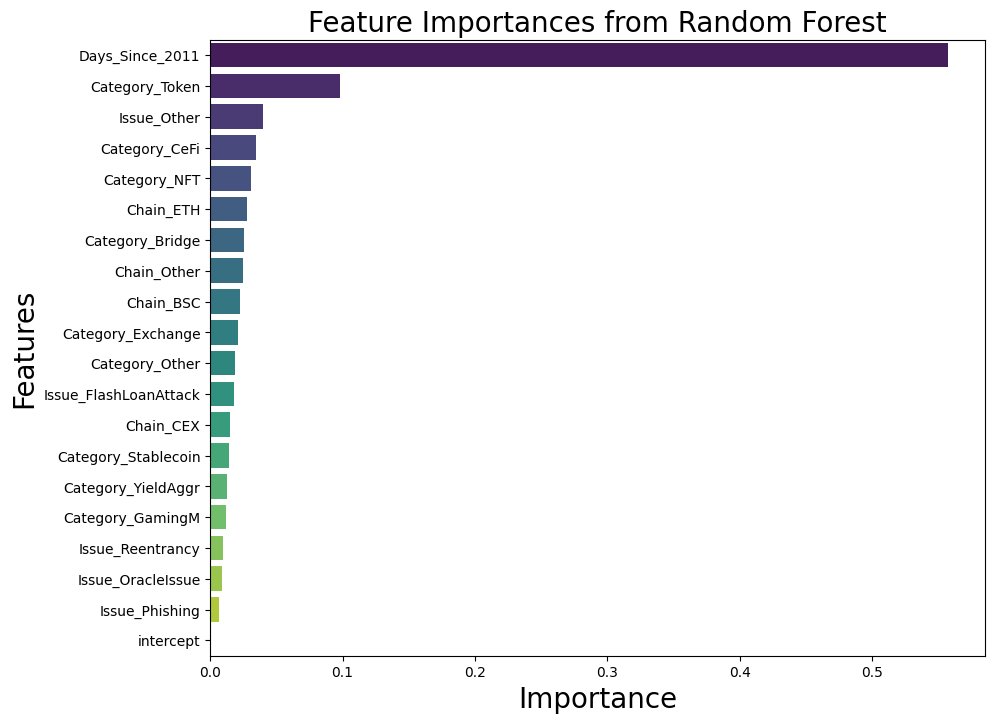

In [24]:
# Initialize and fit a Random Forest Regressor
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

# Predict on the test set and calculate MSE
y_pred_rf = random_forest.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Get feature importances
feature_importance_rf = random_forest.feature_importances_

print(f"Random Forest Test MSE: {mse_rf:.3f}")
#print("Feature importances from Random Forest:", feature_importance_rf)

feature_imp = pd.DataFrame(
{'Importance':feature_importance_rf},
index=feature_names)
feature_imp_sorted = feature_imp.sort_values(by='Importance', ascending=False)
print(feature_imp_sorted)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y=feature_imp_sorted.index, data=feature_imp_sorted, palette='viridis')
plt.title('Feature Importances from Random Forest', fontsize=20)
plt.xlabel('Importance', fontsize=20)
plt.ylabel('Features', fontsize=20)
plt.savefig('RF_feat_imp.eps', format='eps')
plt.show()

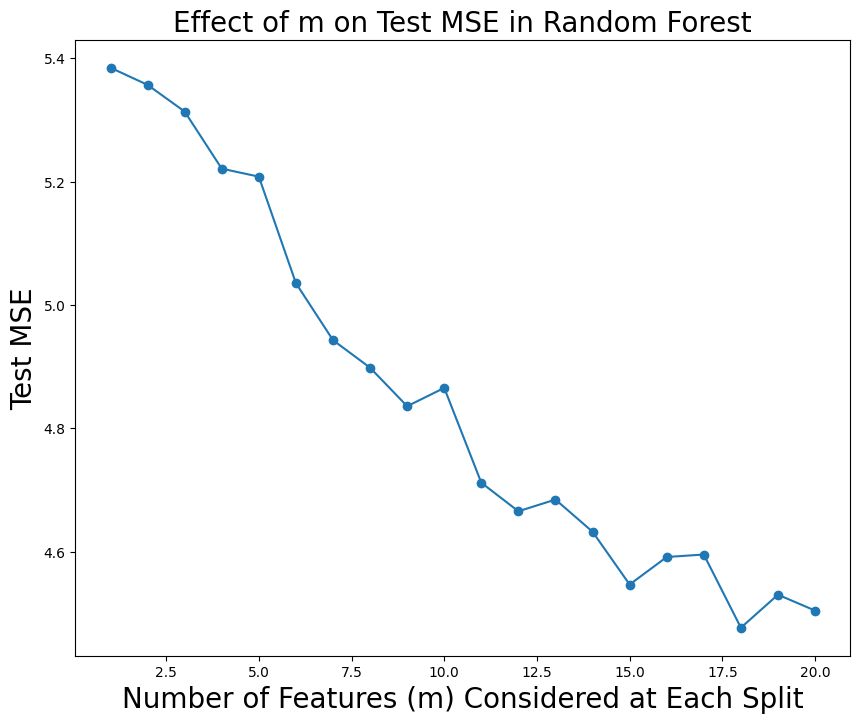

In [25]:
## List to store test MSE values for different m values
m_values = range(1, X_train.shape[1] + 1)  # m values from 1 to the number of features
test_mse_values = []

## Train a Random Forest with different max_features
for max_features in m_values:
    rf_model   = RandomForestRegressor(max_features=max_features, random_state=1, n_estimators=100)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    test_mse = mean_squared_error(y_test, y_pred_rf)
    test_mse_values.append(test_mse)

## Plot the test MSE against m
plt.figure(figsize=(10, 8))
plt.plot(m_values, test_mse_values, marker='o', linestyle='-')
plt.xlabel('Number of Features (m) Considered at Each Split', fontsize=20)
plt.ylabel('Test MSE', fontsize=20)
plt.title('Effect of m on Test MSE in Random Forest', fontsize=20)
plt.savefig('RF_m_MSE.eps', format='eps')
plt.show()

BART Model Test MSE: 4.353


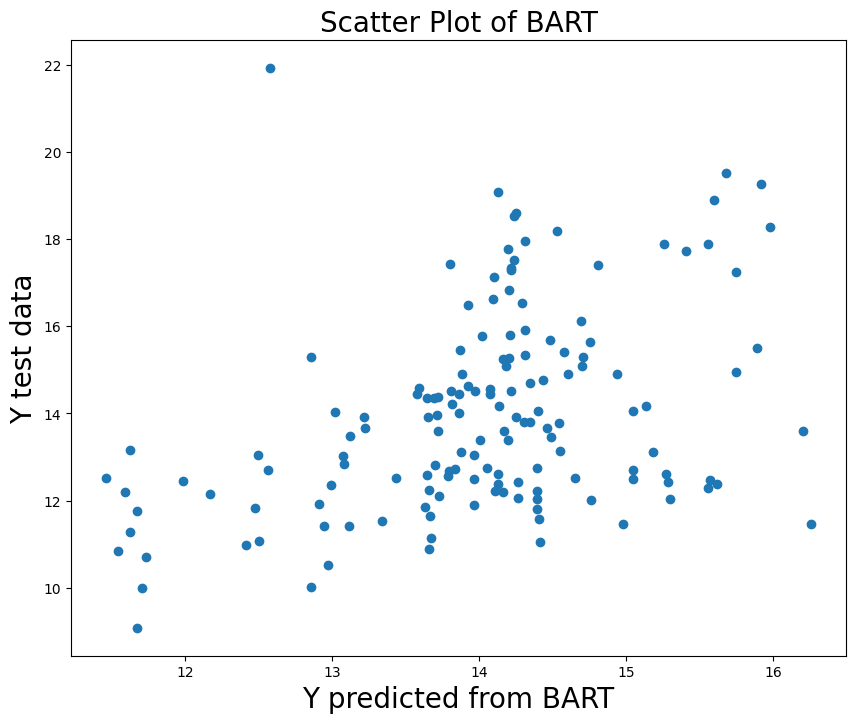

In [26]:
# Ensure numeric types and handle missing values
X_train_encoded = X_train.astype(float).fillna(X_train.mean())
y_train_encoded = y_train.astype(float)

# Train BART model
bart_model = BART(random_state=1, num_trees=100, burnin=100, ndraw=500)
bart_model.fit(X_train_encoded.to_numpy(), y_train_encoded.to_numpy())

# Predict and calculate Test MSE
y_pred_bart = bart_model.predict(X_test.to_numpy())
mse_bart = mean_squared_error(y_test, y_pred_bart)
print('BART Model Test MSE: {}'.format(np.around(mse_bart, 3)))


ax = plt.subplots(figsize=(10,8))[1]
ax.scatter(y_pred_bart , y_test)
plt.xlabel('Y predicted from BART', fontsize=20)
plt.ylabel('Y test data', fontsize=20)
plt.title('Scatter Plot of BART', fontsize=20)
plt.savefig('BART_scatter.eps', format='eps')
plt.show()


In [27]:
# Gradient Boosting
gb = GBR(n_estimators=100, random_state=1)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
test_mse_gb = mean_squared_error(y_test, y_pred_gb)
print("Gradient Boosting Test MSE:", test_mse_gb)

Gradient Boosting Test MSE: 4.253318505878287


In [28]:
# XGBoost
xgb = XGB(n_estimators=100, random_state=1, eval_metric='rmse')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
test_mse_xgb = mean_squared_error(y_test, y_pred_xgb)
print("XGBoost Model Test MSE:", test_mse_xgb)

XGBoost Model Test MSE: 5.772258729979671


In [29]:
warnings.filterwarnings('ignore')

# LightGBM
lgb = LGBMR(n_estimators=100, random_state=1, force_col_wise=True)
lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)
test_mse_lgb = mean_squared_error(y_test, y_pred_lgb)
print("LightGBM Model Test MSE:", test_mse_lgb)

[LightGBM] [Info] Total Bins 230
[LightGBM] [Info] Number of data points in the train set: 597, number of used features: 16
[LightGBM] [Info] Start training from score 14.004433
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

  File "C:\Users\erick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2032.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2032.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2032.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [30]:
# Best boosting approach
best_boosting_mse = min(test_mse_gb, test_mse_xgb, test_mse_lgb)
print("Best Boosting Test MSE:", best_boosting_mse)

Best Boosting Test MSE: 4.253318505878287


## GENERALIZED ADDITIVE MODELS

In [31]:
poly_rm = MS([poly('Days_Since_2011', degree=4)]).fit(data)
M = sm.OLS(y, poly_rm.transform(data)).fit()
summarize(M)

,coef,std err,t,P>|t|
intercept,13.999,0.085,164.207,0.000
"poly(Days_Since_2011, degree=4)[0]",0.290,2.330,0.125,0.901
"poly(Days_Since_2011, degree=4)[1]",-14.321,2.330,-6.146,0.000
"poly(Days_Since_2011, degree=4)[2]",6.646,2.330,2.853,0.004
"poly(Days_Since_2011, degree=4)[3]",9.441,2.330,4.052,0.000


In [32]:
#  see the fitting
rm=data['Days_Since_2011']
rm_grid = np.linspace(rm.min(), rm.max(), 100)
rm_df = pd.DataFrame({'Days_Since_2011': rm_grid})

In [33]:
#define a general plot function
def plot_rm_fit(rm_df, basis_list, titles):
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=(10, 8))

    # Scatter plot of the original data
    ax.scatter(rm, y, facecolor='gray', alpha=0.5, label='Data')

    # Loop through each basis and title to plot each fit
    for basis, title, color in zip(basis_list, titles, ['b', 'g']):
        X = basis.transform(data)
        Xnew = basis.transform(rm_df)
        M = sm.OLS(y, X).fit()
        preds = M.get_prediction(Xnew)
        bands = preds.conf_int(alpha=0.05)

        # Plot the predicted mean and confidence bands
        ax.plot(rm_df.values, preds.predicted_mean, color=color, label=title, linewidth=3)
        ax.plot(rm_df.values, bands[:, 0], f'{color}--', linewidth=1, alpha=0.6)
        ax.plot(rm_df.values, bands[:, 1], f'{color}--', linewidth=1, alpha=0.6)

    # Set title and labels
    ax.set_title('Comparison of Fits', fontsize=20)
    ax.set_xlabel('Days_Since_2011', fontsize=20)
    ax.set_ylabel('Funds Lost', fontsize=20)
    ax.legend(fontsize=15)

    return ax


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


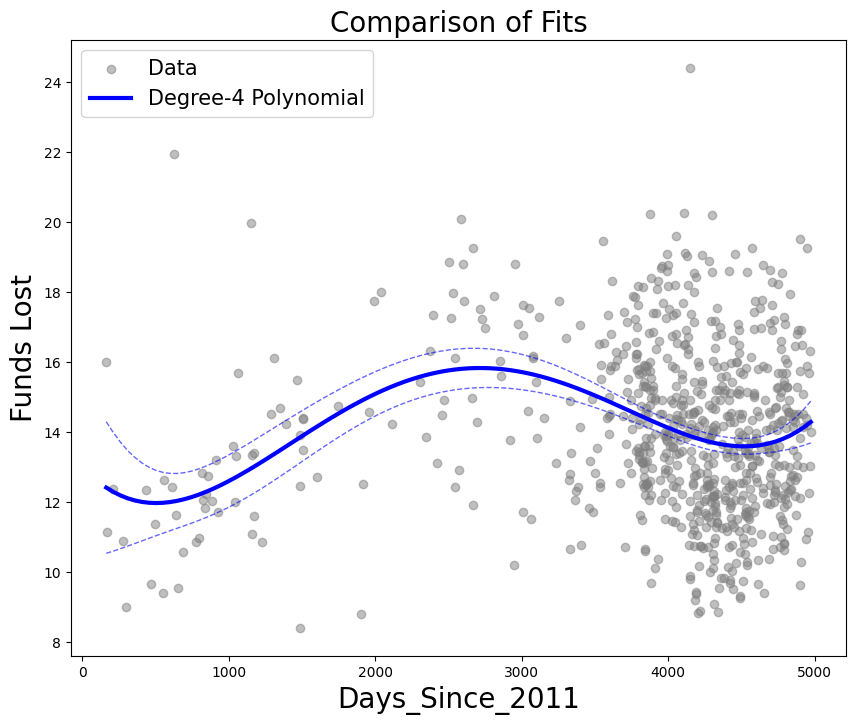

In [34]:
basis_list = [poly_rm]
titles=['Degree-4 Polynomial']
plot_rm_fit(rm_df, basis_list, titles)
plt.savefig('GAM_1.eps', format='eps')
plt.show()

In [35]:
##anova approach to determine the order
models = [MS([poly('Days_Since_2011', degree=d)])
for d in range(1, 6)]
Xs = [model.fit_transform(data) for model in models]
anova_lm(*[sm.OLS(y, X_).fit() for X_ in Xs])

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,745.000,4366.592,0.000,NaN,NaN,NaN
1,744.000,4161.510,1.000,205.082,37.809,0.000
2,743.000,4117.336,1.000,44.174,8.144,0.004
3,742.000,4028.211,1.000,89.125,16.431,0.000
4,741.000,4019.345,1.000,8.866,1.635,0.201


In [36]:
####different rm groups####
cut_rm = pd.qcut(rm , 4)
summarize(sm.OLS(y, pd.get_dummies(cut_rm)).fit())

,coef,std err,t,P>|t|
"(162.999, 3835.5]",14.434,0.173,83.339,0.000
"(3835.5, 4208.0]",14.451,0.173,83.439,0.000
"(4208.0, 4533.5]",13.182,0.174,75.909,0.000
"(4533.5, 4973.0]",13.922,0.173,80.383,0.000


In [37]:
#####cubic spline ######
bs_rm = MS([bs('Days_Since_2011', internal_knots=[1000,1800,2500])])
Xbs = bs_rm.fit_transform(data)
M = sm.OLS(y, Xbs).fit()
summarize(M)


,coef,std err,t,P>|t|
intercept,12.703,1.315,9.661,0.000
"bs(Days_Since_2011, internal_knots=[1000, 1800, 2500])[0]",-2.782,2.389,-1.164,0.245
"bs(Days_Since_2011, internal_knots=[1000, 1800, 2500])[1]",1.884,1.700,1.108,0.268
"bs(Days_Since_2011, internal_knots=[1000, 1800, 2500])[2]",0.288,1.777,0.162,0.871
"bs(Days_Since_2011, internal_knots=[1000, 1800, 2500])[3]",6.103,1.582,3.859,0.000
"bs(Days_Since_2011, internal_knots=[1000, 1800, 2500])[4]",-0.947,1.477,-0.641,0.522
"bs(Days_Since_2011, internal_knots=[1000, 1800, 2500])[5]",1.546,1.340,1.154,0.249


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


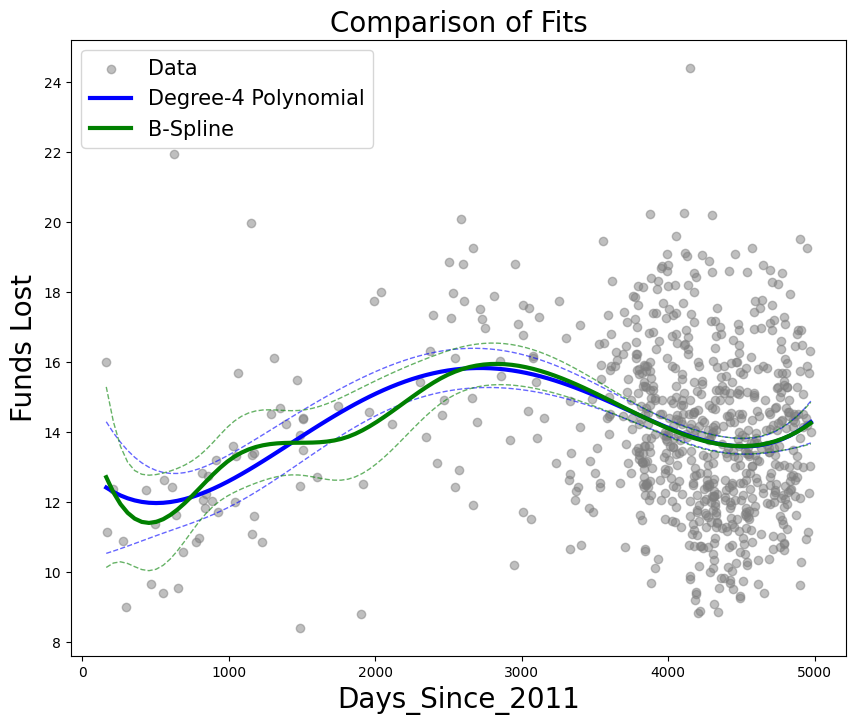

In [38]:
basis_list = [poly_rm, bs_rm]
titles = ['Degree-4 Polynomial', 'B-Spline']

# Plot both curves on the same plot
plot_rm_fit(rm_df, basis_list, titles)
plt.savefig('GAM_2.eps', format='eps')
plt.show()

In [39]:
###specify degree of freedom###
bs_rm0 = MS([bs('Days_Since_2011', df=3, degree=2)]).fit(data)
Xbs0 = bs_rm0.transform(data)
summarize(sm.OLS(y, Xbs0).fit())

,coef,std err,t,P>|t|
intercept,10.420,0.564,18.474,0.000
"bs(Days_Since_2011, df=3, degree=2)[0]",8.044,1.006,7.993,0.000
"bs(Days_Since_2011, df=3, degree=2)[1]",2.450,0.526,4.655,0.000
"bs(Days_Since_2011, df=3, degree=2)[2]",4.157,0.696,5.975,0.000


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


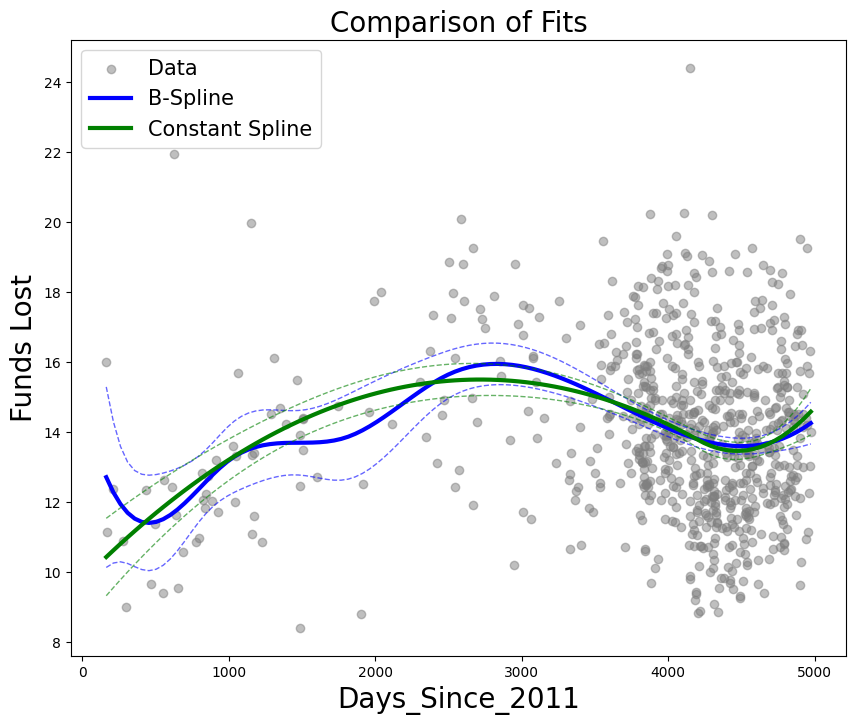

In [40]:
basis_list = [bs_rm, bs_rm0]
titles = ['B-Spline', 'Constant Spline']

# Plot both curves on the same plot
plot_rm_fit(rm_df, basis_list, titles)
plt.savefig('GAM_3.eps', format='eps')
plt.show()

In [41]:
####NaturalSpline###
ns_rm = MS([ns('Days_Since_2011', df=5)]).fit(data)
M_ns = sm.OLS(y, ns_rm.transform(data)).fit()
summarize(M_ns)

,coef,std err,t,P>|t|
intercept,11.439,0.545,20.970,0.000
"ns(Days_Since_2011, df=5)[0]",3.166,0.531,5.962,0.000
"ns(Days_Since_2011, df=5)[1]",1.290,0.670,1.927,0.054
"ns(Days_Since_2011, df=5)[2]",0.818,0.516,1.585,0.113
"ns(Days_Since_2011, df=5)[3]",7.032,1.423,4.942,0.000
"ns(Days_Since_2011, df=5)[4]",0.034,0.516,0.067,0.947


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


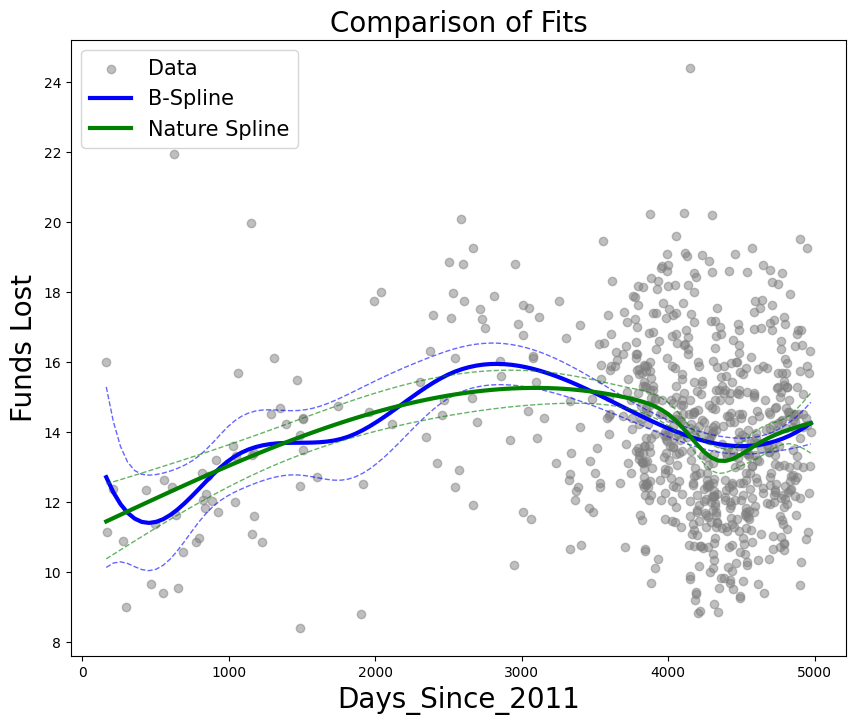

In [42]:
basis_list = [bs_rm, ns_rm]
titles = ['B-Spline', 'Nature Spline']

# Plot both curves on the same plot
plot_rm_fit(rm_df, basis_list, titles)
plt.savefig('GAM_4.eps', format='eps')
plt.show()

In [43]:
X_rm = np.asarray(rm).reshape((-1,1))
gam = LinearGAM(s_gam(0, lam=3.98)).fit(X_rm, y)
gam_opt = gam.gridsearch(X_rm , y)
best_lambda = gam_opt.lam
print(f"Best lambda: {best_lambda}")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Best lambda: [[3.98]]


In [44]:
# Define a modified plot function to include the smoothing spline fit
def plot_rm_fit_extended(rm_df, basis_list, titles, colors):
    fig, ax = plt.subplots(figsize=(10, 8))

    # Scatter plot of the original data
    ax.scatter(rm, y, facecolor='gray', alpha=0.5, label='Original Data')

    # Loop through each basis, title, and color to plot each fit
    for basis, title, color in zip(basis_list, titles, colors):
        if isinstance(basis, LinearGAM):
            # For smoothing spline fit
            y_pred = basis.predict(rm_df.values.reshape(-1, 1))
            ax.plot(rm_df.values, y_pred, color=color, label=title, linewidth=3)
        else:
            # For B-spline and natural spline fits
            X_new = basis.transform(data)
            M = sm.OLS(y, X_new).fit()
            preds = M.get_prediction(basis.transform(rm_df))
            bands = preds.conf_int(alpha=0.05)

            ax.plot(rm_df.values, preds.predicted_mean, color=color, label=title, linewidth=3)
            ax.plot(rm_df.values, bands[:, 0], f'{color}--', linewidth=1, alpha=0.6)
            ax.plot(rm_df.values, bands[:, 1], f'{color}--', linewidth=1, alpha=0.6)

    # Set title and labels
    ax.set_title('Comparison of Spline Fits', fontsize=20)
    ax.set_xlabel('Days_Since_2011', fontsize=20)
    ax.set_ylabel('Funds Lost', fontsize=20)
    ax.legend(fontsize=15)

    return ax

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


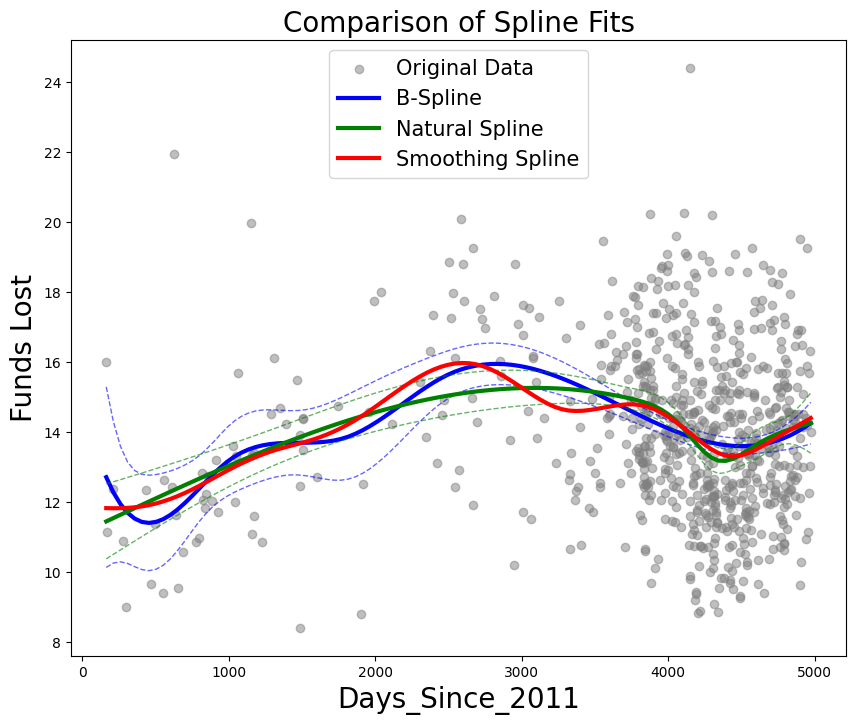

In [45]:
# Plot all spline fits on the same plot
basis_list = [bs_rm, ns_rm, gam]
titles = ['B-Spline', 'Natural Spline', 'Smoothing Spline']
colors = ['b', 'g', 'r']

rm_df = pd.DataFrame({'Days_Since_2011': np.linspace(rm.min(), rm.max(), 100)})
plot_rm_fit_extended(rm_df, basis_list, titles, colors)
plt.savefig('GAM_5.eps', format='eps')
plt.show()

In [46]:
#####GAM model###
# Prepare variables and basis functions for the GAM model
gam = LinearGAM(
    s_gam(0, lam=0.6) +  # Smoothing spline for the first feature ('crim')
    s_gam(1, lam=0.6) +  # Smoothing spline for the second feature ('zn')
    l_gam(2) +           # Linear term for the third feature ('indus')
    f_gam(3) +           # Linear term for the fourth feature (factor 'chas')
    s_gam(4) +           # Smoothing spline for 'nox'
    l_gam(5) +           # Linear term for 'rm'
    s_gam(6) +           # Smoothing spline for 'age'
    l_gam(7) +           # Linear term for 'dis'
    s_gam(8, lam=0.6) +  # Smoothing spline for 'rad'
    l_gam(9) +           # Linear term for 'tax'
    s_gam(10) +          # Smoothing spline for 'ptratio'
    s_gam(11, lam=0.6)   # Smoothing spline for 'lstat'
)

# Fit the model on the training data
gam.fit(X_train, y_train)

# Summarize the model fit
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     21.6657
Link Function:                     IdentityLink Log Likelihood:                                 -1501.7551
Number of Samples:                          597 AIC:                                             3048.8415
                                                AICc:                                            3050.7126
                                                GCV:                                                4.7353
                                                Scale:                                               4.427
                                                Pseudo R-Squared:                                   0.2891
Feature Function                  Lam

In [47]:
# Predict on the test set
y_pred = gam.predict(X_test)

# Calculate mean squared error on test set
mse = mean_squared_error(y_test, y_pred)
print(f"GAM Model Test MSE: {mse:.4f}")

GAM Model Test MSE: 4.8012


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


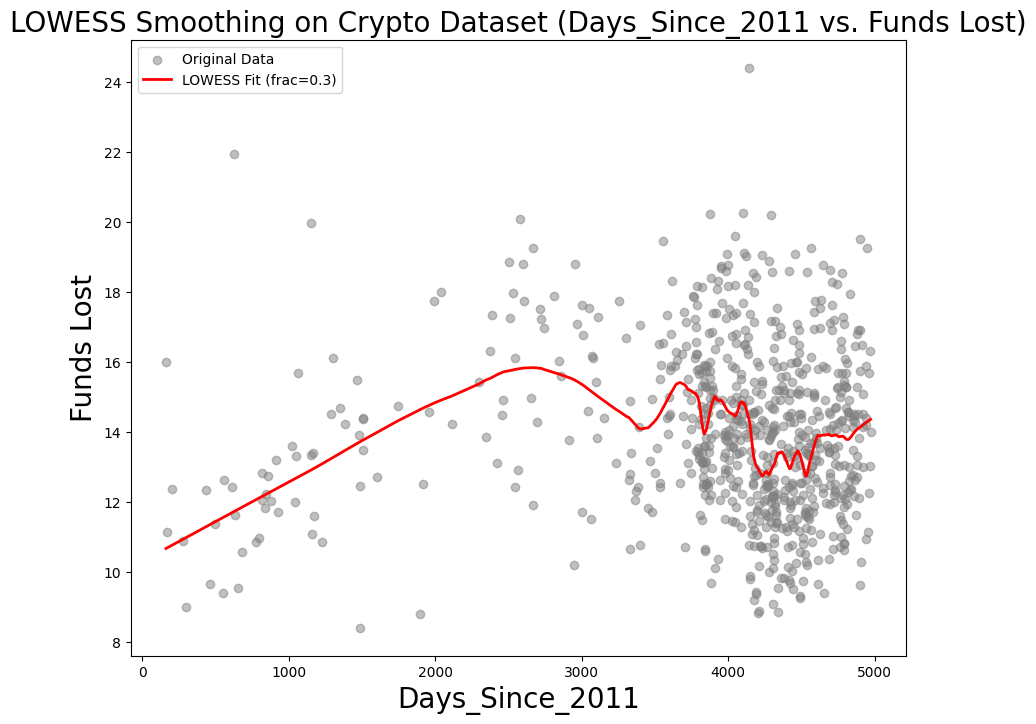

In [48]:
# Apply LOWESS smoothing
lowess_fit = sm.nonparametric.lowess(y, rm, frac=0.1)

# Extract the smoothed x and y values
rm_smoothed = lowess_fit[:, 0]
medv_smoothed = lowess_fit[:, 1]

# Plot the original data and the LOWESS fit
plt.figure(figsize=(10, 8))
plt.scatter(rm, y, facecolor='gray', alpha=0.5, label='Original Data')
plt.plot(rm_smoothed, medv_smoothed, color='r', label='LOWESS Fit (frac=0.3)', linewidth=2)
plt.xlabel('Days_Since_2011', fontsize=20)
plt.ylabel('Funds Lost', fontsize=20)
plt.title('LOWESS Smoothing on Crypto Dataset (Days_Since_2011 vs. Funds Lost)', fontsize=20)
plt.legend()
plt.savefig('GAM_6.eps', format='eps')
plt.show()

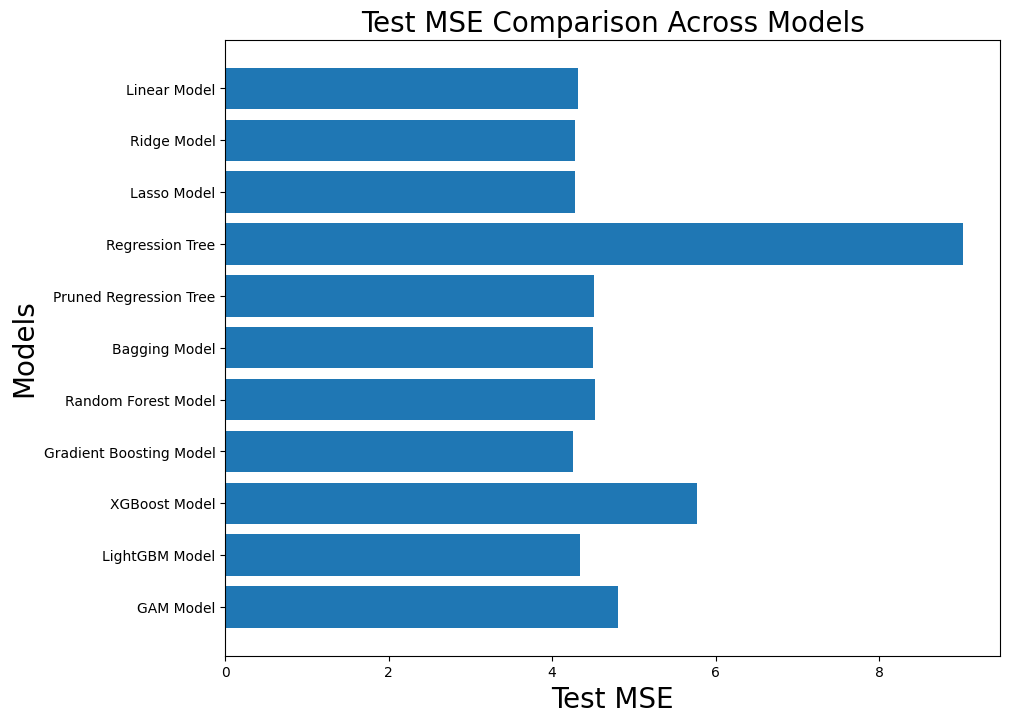

In [49]:
# Data
models = [
    "Linear Model", "Ridge Model", "Lasso Model", "Regression Tree",
    "Pruned Regression Tree", "Bagging Model", "Random Forest Model",
    "Gradient Boosting Model", "XGBoost Model", "LightGBM Model", "GAM Model"
]
mse_values = [4.314, 4.286, 4.278, 9.031, 4.516, 4.503, 4.524, 4.253, 5.772, 4.339, 4.801]

# Plot
plt.figure(figsize=(10, 8))
plt.barh(models, mse_values)
plt.xlabel("Test MSE", fontsize=20)
plt.ylabel("Models", fontsize=20)
plt.title("Test MSE Comparison Across Models", fontsize=20)
plt.gca().invert_yaxis()  # Reverse order to show the lowest MSE at the top
plt.savefig('Model_comparison.eps', format='eps')
plt.show()
